In [27]:
# Down stream application: PID tuning
import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time, sys, datetime
from scipy.optimize import minimize, differential_evolution
import rootpath
root_dir = rootpath.detect()   # Get the root directory of the project (.git)
from pathlib import Path
# sys.path.append(str(Path(root_dir)))
sys.path.append("/Users/flypig/Documents/Coding/MujocoLearn")
print(root_dir)

from utils.experiment import MujocoExperiment

# In some way, PID experiment is the specific child class of the MujocoExperiment
class Downstream_PID_experiment(object):
    def __init__(self):
        path = root_dir + "/models/SingleLeg_ideal.xml"
        self.experiment_instance = MujocoExperiment(path, model_type="ideal_geom_swing")
        
        # Model Parameter Set
        params = {
            'stiffness_MAA': 318.76,
            'stiffness_BAA': 315.8,
            'l10': 0.174,
            'l20': 0.2562,
            'damping_MAA': 11.34,
            'damping_BAA': 10.9,
            's1': 0.000654,
            's2': 0.000637,
            'c1_thigh': 0,
            'c2_calf': 0,
            'P1': 0,
            'P2': 0,
            'P1_prime': 0,
            'P2_prime': 0
        }
        self.experiment_instance.apply_params(params)

        # Run the Experiments
        self.framerate = 60

    def simulate_response_evaluate_pid(self, Kp, Ki, Kd, mode="optimize"):

        # exp_set
        duration_steady = 10  # seconds, the steady state time
        duration_experiment = 10  # seconds, the experiment time
        ifrender = True

        m, d = self.experiment_instance.model, self.experiment_instance.data

        # Reset state and time
        mujoco.mj_resetData(m, d)

        # Reset state and time
        results = []
        frames = []
        dt = m.opt.timestep

        # PID
        err_sum = [0.0, 0.0]
        last_err = [0.0, 0.0]
        error_list = []
        total_error = 0.0

        with mujoco.Renderer(m, self.experiment_instance.height, self.experiment_instance.width) as renderer:
            while d.time < duration_steady + duration_experiment:
                theta1 = d.qpos[0] + np.pi / 2
                theta2 = d.qpos[1] + 0
                u1 = 0
                u2 = 0
                l1, l2 = MujocoExperiment.calculate_length(theta1, theta2)
                l1_target, l2_target = MujocoExperiment.calculate_length(math.pi/2, 0)
                if d.time >= duration_steady:
                    err1 = l1_target - l1
                    err2 = l2_target - l2
                    err_sum[0] += err1 * dt
                    err_sum[1] += err2 * dt
                    derr1 = (err1 - last_err[0]) / dt
                    derr2 = (err2 - last_err[1]) / dt
                    u1 = Kp * err1 + Ki * err_sum[0] + Kd * derr1
                    u2 = Kp * err2 + Ki * err_sum[1] + Kd * derr2
                    # limit u1, u2 in [-100, 100]
                    u1 = np.clip(u1, -100, 100)
                    u2 = np.clip(u2, -100, 100)
                    last_err = [err1, err2]
                    d.ctrl[:2] = u1
                    d.ctrl[2:] = u2
                    total_error += err1**2 + err2**2
                    error_list.append(err1**2 + err2**2)
                else:
                    d.ctrl[:] = 0
                # update
                mujoco.mj_step(m, d)
                if mode == "validate":
                    if len(frames) < d.time * self.framerate:   # assume the simulation is running much faster than the rendering
                        if ifrender:
                            renderer.update_scene(d, camera="closeup")
                            frames.append(renderer.render())
                    results.append((d.time, theta1, theta2, u1, u2))
            if mode == "validate":
                time_sim, theta1_sim, theta2_sim, u1, u2 = np.array(results).T
                return time_sim, theta1_sim, theta2_sim, u1, u2, frames
            else:
                return np.mean(np.array(error_list))


# if __name__ == "__main__":
mySim = Downstream_PID_experiment()

print("Begin optimization for PID parameters...")
pid_history = []
def pid_objective(x):
    Kp, Ki, Kd = x
    # Evaluate the PID parameters
    res = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd)
    return res

def record_best_x_2(xk):
    Kp, Ki, Kd = xk
    res = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd)
    pid_history.append((Kp, Ki, Kd, res))
    print(f"Evaluating PID: Kp={Kp}, Ki={Ki}, Kd={Kd}, Total Error={res}")

def record_best_x(xk, convergence):
    Kp, Ki, Kd = xk
    res = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd)
    pid_history.append((Kp, Ki, Kd, res))
    print(f"Evaluating PID: Kp={Kp}, Ki={Ki}, Kd={Kd}, Total Error={res}")

# 初始猜测
x0 = [100.0, 0.0, 2.0]

time_init, theta1_init, theta2_init, u1_init, u2_init, frames_init = mySim.simulate_response_evaluate_pid(*x0, mode="validate")

# 加边界限制
bounds = [(1, 10000), (0, 1000), (0, 100)]

res_local = minimize(pid_objective, x0, bounds=bounds, method='L-BFGS-B', callback=record_best_x_2, options={'disp': True, 'maxiter': 1000})

# bounds: [(min1, max1), (min2, max2), (min3, max3)]
min_bounds = np.array([b[0] for b in bounds])
max_bounds = np.array([b[1] for b in bounds])

init_population = [
    np.clip(res_local.x * (1+np.random.uniform(-1.0, 9.0, size=3)), min_bounds, max_bounds)
    for _ in range(10)
]

res = differential_evolution(pid_objective, init=init_population, bounds=bounds, popsize=10, disp=True, callback=record_best_x,  strategy='rand1bin', mutation=(0.05, 0.2))

print("Best PID:", res.x)

# record the best result
time_best, theta1_best, theta2_best, u1_best,  u2_best, frames_best = mySim.simulate_response_evaluate_pid(*res.x, mode="validate")


/Users/flypig/Documents/Coding/MujocoLearn
Begin optimization for PID parameters...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         1 variables are exactly at the bounds

At iterate    0    f=  3.77287D-03    |proj g|=  8.50404D-05

At iterate    1    f=  3.77286D-03    |proj g|=  8.50401D-05
Evaluating PID: Kp=100.00001704202086, Ki=8.504035149681233e-05, Kd=1.9999996026182174, Total Error=0.003772863920483988

At iterate    2    f=  1.79446D-03    |proj g|=  2.91137D-05
Evaluating PID: Kp=113.89119050649485, Ki=35.96067798924386, Kd=8.347471253992712, Total Error=0.001794455556249145

At iterate    3    f=  1.33674D-03    |proj g|=  1.81760D-05
Evaluating PID: Kp=120.78165597398727, Ki=54.5268337439597, Kd=11.0241323393669, Total Error=0.0013367358104012122

At iterate    4    f=  9.03199D-04    |proj g|=  9.28438D-06
Evaluating PID: Kp=132.86656278189972, Ki=85.31278628358935, Kd=14.32491078506748, Tota

In [28]:
pid_history


[(np.float64(100.00001704202086),
  np.float64(8.504035149681233e-05),
  np.float64(1.9999996026182174),
  np.float64(0.003772863920483988)),
 (np.float64(113.89119050649485),
  np.float64(35.96067798924386),
  np.float64(8.347471253992712),
  np.float64(0.001794455556249145)),
 (np.float64(120.78165597398727),
  np.float64(54.5268337439597),
  np.float64(11.0241323393669),
  np.float64(0.0013367358104012122)),
 (np.float64(132.86656278189972),
  np.float64(85.31278628358935),
  np.float64(14.32491078506748),
  np.float64(0.0009031989549218056)),
 (np.float64(1303.7456033099925),
  np.float64(558.6152134390741),
  np.float64(8.600212603715413),
  np.float64(4.884878792686762e-05)),
 (np.float64(1303.7456033099925),
  np.float64(558.6152134390741),
  np.float64(8.600212603715413),
  np.float64(4.884878792686762e-05)),
 (np.float64(1158.613672301688),
  np.float64(679.2096393444266),
  np.float64(8.021566411385166),
  np.float64(4.4953598949849375e-05)),
 (np.float64(1281.2048237147055),

In [10]:

print(f"Simulation finished at: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
dt_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
video_filename = root_dir + f"/src/application/PID/video/PID_{dt_str}.mp4"
media.write_video(video_filename, frames_best, fps=mySim.framerate)



Simulation finished at: 2025-07-25 01:36:34


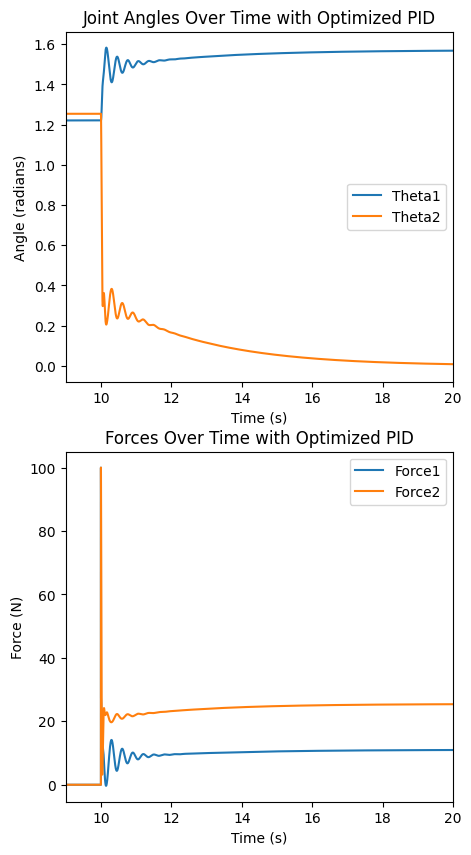

In [29]:
duration_steady = 10  # seconds, the steady state time
duration_experiment = 10  # seconds, the experiment time

# plot
plt.figure(figsize=(5, 10))
plt.subplot(2,1,1) #图一包含1行2列子图，当前画在第一行第一列图上
plt.plot(time_best, theta1_best, label='Theta1')
plt.plot(time_best, theta2_best, label='Theta2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlim(duration_steady-1, duration_steady + duration_experiment)

plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.title('Joint Angles Over Time with Optimized PID')
plt.legend()

# plot
plt.subplot(2,1,2) #图一包含1行2列子图，当前画在第一行第一列图上
plt.plot(time_best, u1_best, label='Force1')
plt.plot(time_best, u2_best, label='Force2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlim(duration_steady-1, duration_steady + duration_experiment)

plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Forces Over Time with Optimized PID')
plt.legend()
plt.show()


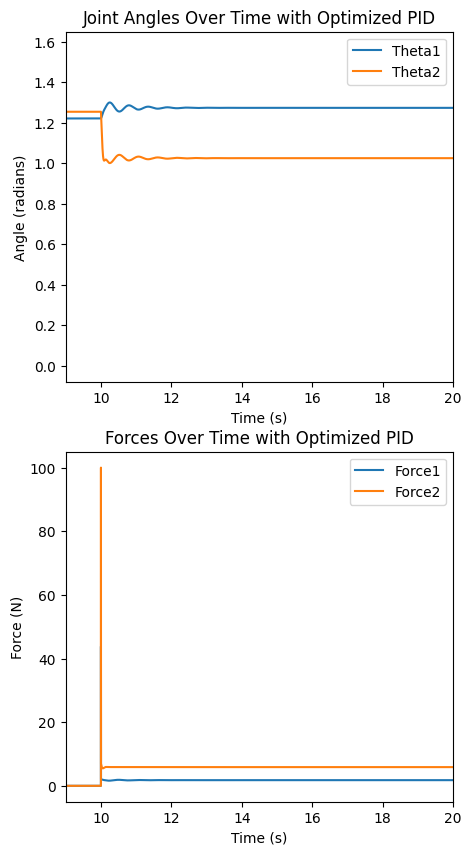

In [30]:
# plot
plt.figure(figsize=(5, 10))
plt.subplot(2,1,1) #图一包含1行2列子图，当前画在第一行第一列图上
plt.plot(time_init, theta1_init, label='Theta1')
plt.plot(time_init, theta2_init, label='Theta2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlim(duration_steady-1, duration_steady + duration_experiment)

plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.title('Joint Angles Over Time with Optimized PID')
plt.legend()

# plot
plt.subplot(2,1,2) #图一包含1行2列子图，当前画在第一行第一列图上
plt.plot(time_init, u1_init, label='Force1')
plt.plot(time_init, u2_init, label='Force2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlim(duration_steady-1, duration_steady + duration_experiment)

plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Forces Over Time with Optimized PID')
plt.legend()
plt.show()

In [31]:
time_best, theta1_best, theta2_best, u1_best,  u2_best, frames_best = mySim.simulate_response_evaluate_pid(*pid_history[0][0:3], mode="validate")
media.show_video(frames_best, fps=mySim.framerate)

This browser does not support the video tag.
